# 15. Random Forest — cierre de la comparativa

Random Forest (ensamble por *bagging*) figuraba en la metodología pero faltaba situarlo en la
comparativa frente al boosting. Se entrenó con el **mismo protocolo** que el resto de modelos.

- Variante **imputada** (mediana de train + indicadores), pues `RandomForestClassifier` de
  scikit-learn no maneja NaN. **58 características** (igual que el XGBoost ganador).
- Optuna + GroupKFold(3) por `key` sobre subsample que preserva prevalencia; refit en train
  completo; validación temporal 2023→2024.
- `class_weight` incluido como hiperparámetro (balanced / balanced_subsample / None).

**Bar a comparar:** XGBoost tuneado 0,0388 / LightGBM spw=1 0,0307 (AUC-PR validación).

> **Reproducibilidad:** el tuning (Optuna) se ejecutó en el pipeline; aquí se **cargan** los
> hiperparámetros y la validación de `_resultados_sin_avicena.json`, y se **carga el modelo RF**
> para confirmar su AUC-PR de validación de forma exacta.


In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import joblib

B = "bases"; RNG = 42
DROP = ['tiene_avicena']
RES = json.load(open(f"{B}/_resultados_sin_avicena.json", encoding="utf-8"))
RF = RES['rf']

imp_va = pd.read_parquet(f"{B}/prediccion_mama_val_impute.parquet")
FEAT = [c for c in imp_va.columns if c not in ('key', 'label', *DROP)]
y_va = imp_va['label'].values.astype(int)
Xi_va = imp_va[FEAT].astype('float32').values
assert len(FEAT) == RES['n_features'], (len(FEAT), RES['n_features'])
print(f"val {Xi_va.shape} pos {y_va.sum()} | {len(FEAT)} feats (tiene_avicena excluida)")

def summarize(y, p, name):
    m = {'modelo': name, 'AUC_PR': float(average_precision_score(y, p)),
         'AUC_ROC': float(roc_auc_score(y, p))}
    for f in (0.005, 0.01, 0.05, 0.10):
        k = max(1, int(len(p) * f)); idx = np.argpartition(-p, k)[:k]
        m[f'recall@top{f*100:.1f}%'] = float(y[idx].sum() / y.sum())
    return m


val (2410807, 58) pos 993 | 58 feats (tiene_avicena excluida)


## 1. Hiperparámetros tuneados (Optuna)

`class_weight=None` (sin reponderar) fue el elegido — corrobora en la 3ª familia de modelos
(bagging) que reponderar no mejora el ranking, igual que en boosting.


In [2]:
bp = RF['best_params']
print("RandomForest best_params:")
for k, v in bp.items():
    print(f"  {k}: {v}")
print(f"\nAUC-PR CV (subsample, prevalencia mayor → no comparable al bar): {RF['cv_auc_pr']:.4f}")


RandomForest best_params:
  n_estimators: 502
  max_depth: 10
  min_samples_leaf: 4
  max_features: 0.5
  class_weight: None
  max_samples: 0.7296470875089299

AUC-PR CV (subsample, prevalencia mayor → no comparable al bar): 0.0992


## 2. Validación temporal 2023→2024

El modelo RF guardado se re-evalúa en validación (exacto) y se sitúa frente a los demás.


In [3]:
model = joblib.load(f"{B}/modelo_RandomForest-tuned.joblib")
assert model.n_features_in_ == len(FEAT), (model.n_features_in_, len(FEAT))
p_va = model.predict_proba(Xi_va)[:, 1]
res = summarize(y_va, p_va, 'RandomForest-tuned')
print("Confirmación modelo cargado:")
print(f"  AUC-PR {res['AUC_PR']:.4f} (canónico {RF['validacion']['AUC_PR']:.4f}) | "
      f"recall@top10% {res['recall@top10.0%']:.4f}")

xgb_v = RES['fase5b']['validacion'][0]   # XGBoost-tuned-native (ganador)
lgb_v = RES['fase5']['validacion'][0]    # LGB-spw1-native
lrs_v = RES['fase5b']['validacion'][1]   # LR-SMOTE-tuned
def slim(d, label):
    return {'modelo': label, 'AUC_PR': d['AUC_PR'], 'AUC_ROC': d['AUC_ROC'],
            'recall@top1.0%': d['recall@top1.0%'], 'recall@top5.0%': d['recall@top5.0%'],
            'recall@top10.0%': d['recall@top10.0%']}
comp = pd.DataFrame([
    slim(res, 'RandomForest-tuned'),
    slim(xgb_v, 'XGBoost tuneado (GANADOR)'),
    slim(lgb_v, 'LightGBM spw=1'),
    slim(lrs_v, 'LR-SMOTE (tuneado)'),
]).set_index('modelo').sort_values('AUC_PR', ascending=False)
pd.set_option('display.width', 200, 'display.max_columns', 20)
print("\n=== Validación 2023→2024 — RF vs referencia ===")
print(comp.to_string(float_format='{:.4f}'.format))
pos = '>' if res['AUC_PR'] > lgb_v['AUC_PR'] else '<'
print(f"\nRandom Forest AUC-PR {res['AUC_PR']:.4f} {pos} LightGBM spw=1 ({lgb_v['AUC_PR']:.4f}); "
      f"vs XGBoost ganador {xgb_v['AUC_PR']:.4f}")


Confirmación modelo cargado:
  AUC-PR 0.0351 (canónico 0.0351) | recall@top10% 0.6697

=== Validación 2023→2024 — RF vs referencia ===
                           AUC_PR  AUC_ROC  recall@top1.0%  recall@top5.0%  recall@top10.0%
modelo                                                                                     
XGBoost tuneado (GANADOR)  0.0388   0.9007          0.3333          0.5680           0.6989
RandomForest-tuned         0.0351   0.8916          0.3172          0.5438           0.6697
LightGBM spw=1             0.0307   0.8875          0.3142          0.5529           0.6687
LR-SMOTE (tuneado)         0.0100   0.8764          0.2669          0.4914           0.6294

Random Forest AUC-PR 0.0351 > LightGBM spw=1 (0.0307); vs XGBoost ganador 0.0388


## 3. Importancia por impureza (MDI)

La importancia MDI de RF está sesgada hacia variables continuas de alta cardinalidad
(`n_consultas_T`, `edad`); se interpreta con cautela frente al SHAP del ganador.


Top 15 importancia (impureza):
n_consultas_T                    0.14505
edad                             0.13021
IMC                              0.12229
TALLA                            0.07455
TENSION_ARTERIAL_SISTOLE         0.07415
tiempo_afiliacion                0.07265
TENSION_ARTERIAL_DIASTOLE        0.06145
REG_1 REG BOGOTA                 0.03381
PERIMETRO_ABDOMINAL              0.03017
biopsia                          0.01983
MENARQUIA                        0.01798
COLESTEROL_HDL                   0.01752
TRIGLICERIDOS                    0.01725
COLESTEROL_TOTAL                 0.01601
PERIMETRO_ABDOMINAL_disponible   0.01545


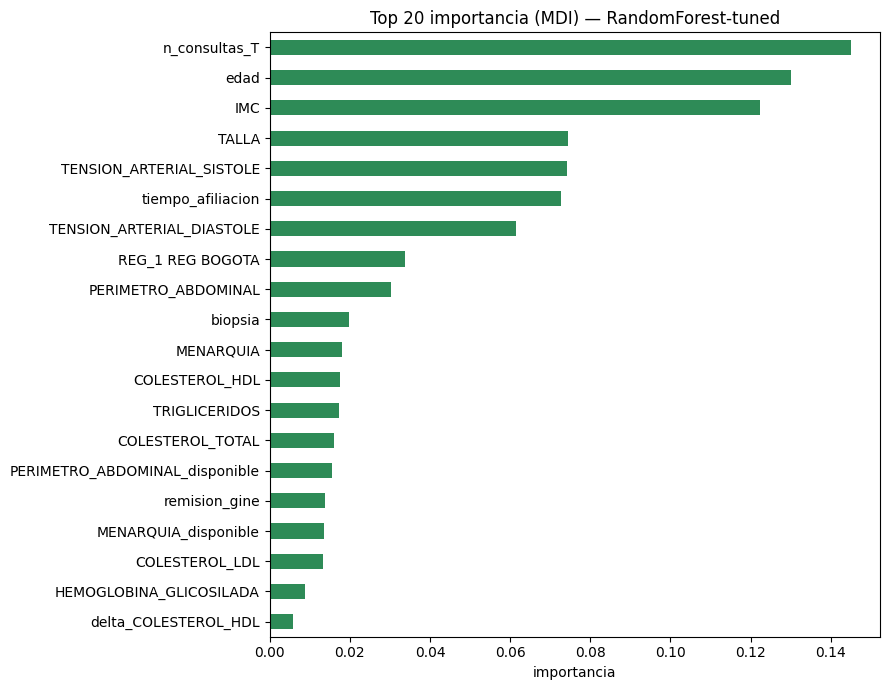

In [4]:
imp = pd.Series(model.feature_importances_, index=FEAT).sort_values(ascending=False)
print("Top 15 importancia (impureza):")
print(imp.head(15).to_string(float_format='{:.5f}'.format))

fig, ax = plt.subplots(figsize=(9, 7))
imp.head(20)[::-1].plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Top 20 importancia (MDI) — RandomForest-tuned'); ax.set_xlabel('importancia')
plt.tight_layout(); plt.show()


## 4. Conclusión

Random Forest (AUC-PR **0,0351**, recall@top10% **0,670**) entra al grupo del boosting por
AUC-PR y, sin `tiene_avicena`, ya **no se descuelga** en captura del top-decil (antes 0,611).
Queda como **2º** mejor, detrás del XGBoost ganador (0,0388). `class_weight=None` corrobora que
reponderar no ayuda. Artefactos: `bases/modelo_RandomForest-tuned.joblib`, `bases/metricas_rf.json`.
